In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df_clean = pd.read_csv("FINAL_facebook_ads_dataset.csv")

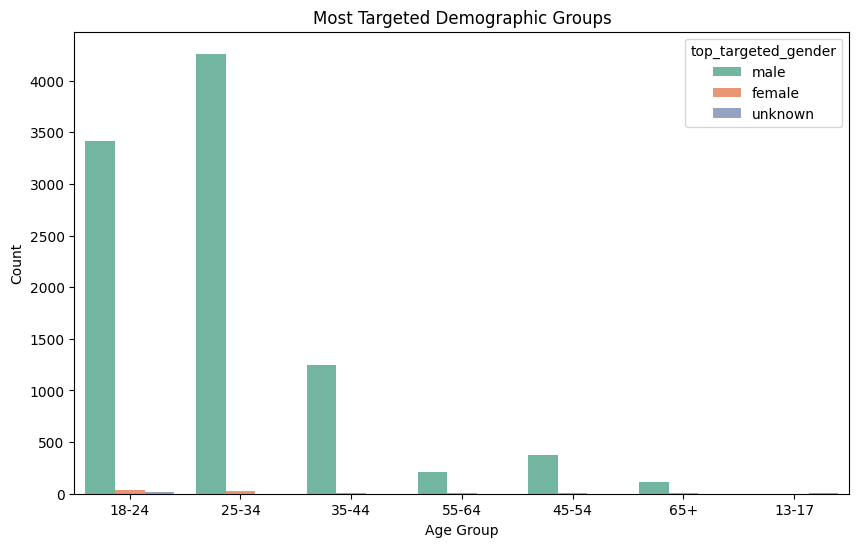

In [3]:
#OBJECTIVE 1 (UNIT III) - DEMOGRAPHICS
demo_df=df_clean[(df_clean['top_targeted_age']!='Unknown')&(df_clean['top_targeted_gender']!='Unknown')]
plt.figure(figsize=(10,6))
sns.countplot(data=demo_df,x='top_targeted_age',hue='top_targeted_gender',palette='Set2')
plt.title("Most Targeted Demographic Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

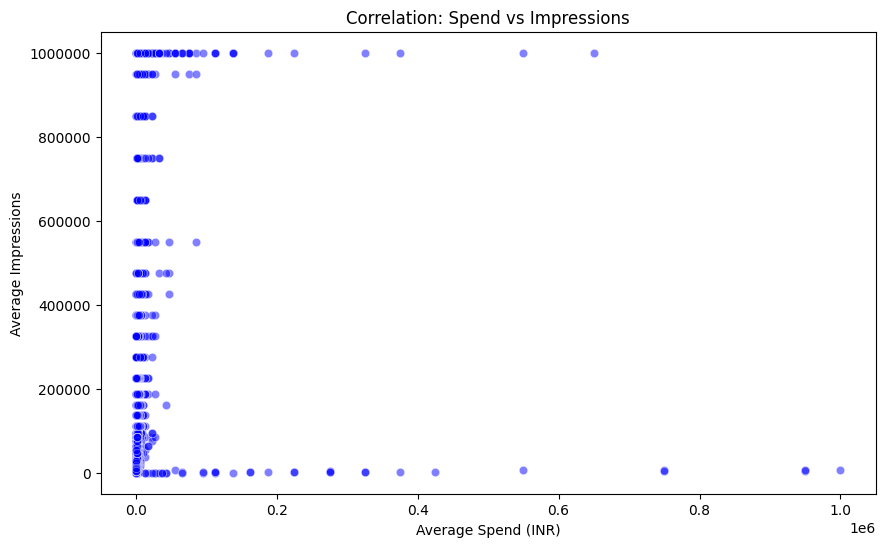

In [4]:
#OBJECTIVE 2 (UNIT III) - SPEND VS IMPRESSIONS CORRELATION
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean,x='avg_spend',y='avg_impressions',alpha=0.5,color='blue')
plt.title("Correlation: Spend vs Impressions")
plt.xlabel("Average Spend (INR)")
plt.ylabel("Average Impressions")
plt.ticklabel_format(style='plain',axis='y')
plt.show()

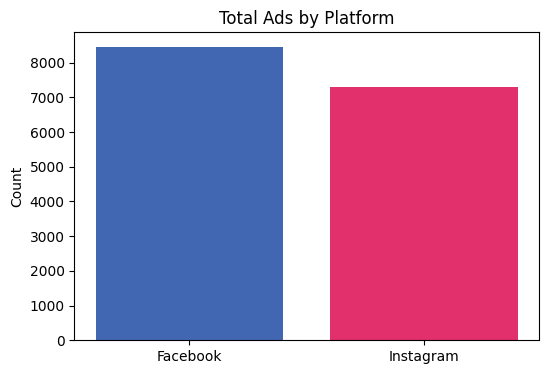

In [5]:
#OBJECTIVE 3 (UNIT III) - PLATFORM STRATEGY
plt.figure(figsize=(6,4))
platform_counts=[df_clean['on_facebook'].sum(),df_clean['on_instagram'].sum()]
platforms=['Facebook','Instagram']
plt.bar(platforms,platform_counts,color=['#4267B2','#E1306C'])
plt.title("Total Ads by Platform")
plt.ylabel("Count")
plt.show()

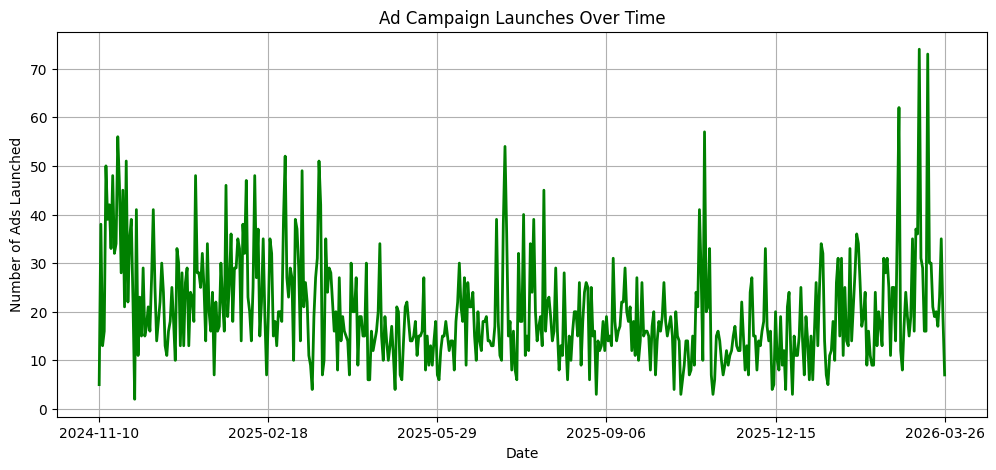

In [6]:
#OBJECTIVE 4 (UNIT III) - TIME SERIES
plt.figure(figsize=(12,5))
daily_ads=df_clean.groupby('ad_delivery_start_time').size()
daily_ads.plot(kind='line',color='green',linewidth=2)
plt.title("Ad Campaign Launches Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Ads Launched")
plt.grid(True)
plt.show()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import norm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load data if starting fresh
df_clean = pd.read_csv("FINAL_facebook_ads_dataset.csv")

# =========================================================
# OBJECTIVE 5 (UNIT IV): Z-TEST (HYPOTHESIS TESTING)
# =========================================================
print("--- Objective 5: One-Sample Z-Test ---")
# Hypothesis: Does the average spend of political ads significantly differ from a hypothetical micro-budget standard of ₹100?

sample_data = df_clean['avg_spend'].dropna()
sample_mean = sample_data.mean()
population_mean = 100  # Our assumed standard budget
population_std_dev = sample_data.std() 
sample_size = len(sample_data)
alpha = 0.05
tail = 'two'

# standard error
standard_error = population_std_dev / math.sqrt(sample_size)

# Z-score
z_score = (sample_mean - population_mean) / standard_error

# p-value based on the type of test
if tail == 'two':
    p_value = 2 * (1 - norm.cdf(abs(z_score)))
elif tail == 'left':
    p_value = norm.cdf(z_score)
elif tail == 'right':
    p_value = 1 - norm.cdf(z_score)

# output
if p_value < alpha:
    conclusion = "Reject the null hypothesis. There is a significant difference."
else:
    conclusion = "Fail to reject the null hypothesis. No significance."

print(f"Sample Mean: {sample_mean:.2f}")
print(f"Z-score: {z_score:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Conclusion: {conclusion}\n")

--- Objective 5: One-Sample Z-Test ---
Sample Mean: 2440.24
Z-score: 9.1491
P-value: 0.0000
Conclusion: Reject the null hypothesis. There is a significant difference.



--- Objective 6: Linear Regression ---
mean square error:  27431284575.96
r2 value:  -0.05569803679519536
Intercept: 70593.21
Coefficient: 1.38


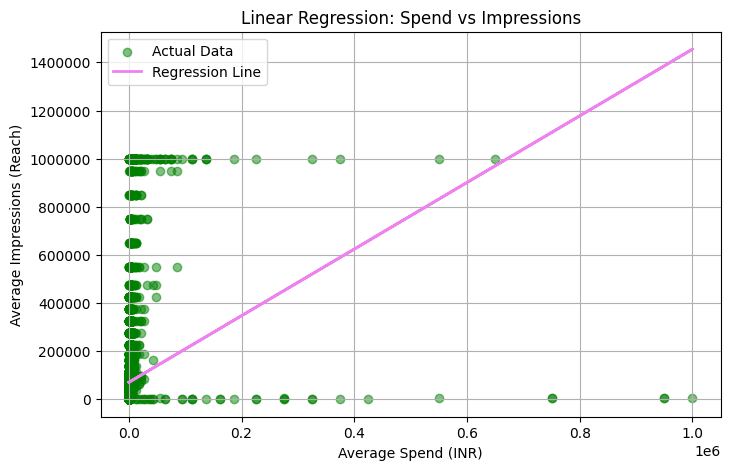

Predicted impressions of a (5000 INR Spend): 
 [77513.51025636]


In [8]:
# OBJECTIVE 6 (UNIT V/VI): MACHINE LEARNING (LINEAR REGRESSION)
# =========================================================
print("--- Objective 6: Linear Regression ---")

# Predicting Impressions based on Ad Spend
X = df_clean[['avg_spend']].values
y = df_clean['avg_impressions'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# model 
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("mean square error: ", mse)
print("r2 value: ", r2)
print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficient: {model.coef_[0]:.2f}")

# Plotting the results 
plt.figure(figsize=(8,5))
plt.scatter(X, y, color='green', label='Actual Data', alpha=0.5)
plt.plot(X, model.predict(X), color='violet', linewidth=2, label='Regression Line')
plt.xlabel("Average Spend (INR)")
plt.ylabel("Average Impressions (Reach)")
plt.title("Linear Regression: Spend vs Impressions")
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# Predicting a new custom value
a = np.array([[5000]]) # Predicting reach for a 5,000 INR budget
predicted_reach = model.predict(a)
print("Predicted impressions of a (5000 INR Spend): \n", predicted_reach)

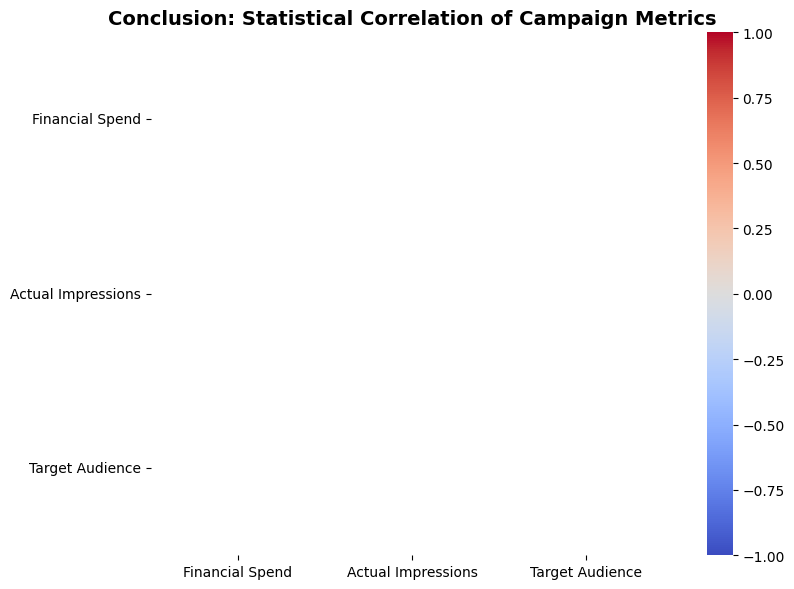

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df_clean = pd.read_csv("FINAL_facebook_ads_dataset.csv")

# 2. FORCE the columns to be numeric (this removes weird text/errors and turns them to NaN)
df_clean['spend'] = pd.to_numeric(df_clean['spend'], errors='coerce')
df_clean['impressions'] = pd.to_numeric(df_clean['impressions'], errors='coerce')
df_clean['estimated_audience_size'] = pd.to_numeric(df_clean['estimated_audience_size'], errors='coerce')

# 3. Select the columns and calculate correlation
numeric_cols = df_clean[['spend', 'impressions', 'estimated_audience_size']]
corr_matrix = numeric_cols.corr()

# 4. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    linewidths=1,
    square=True
)

plt.title('Conclusion: Statistical Correlation of Campaign Metrics', fontsize=14, fontweight='bold')
plt.xticks(ticks=[0.5, 1.5, 2.5], labels=['Financial Spend', 'Actual Impressions', 'Target Audience'], rotation=0)
plt.yticks(ticks=[0.5, 1.5, 2.5], labels=['Financial Spend', 'Actual Impressions', 'Target Audience'], rotation=0)

plt.tight_layout()
plt.show()